In [ ]:
from galaxy_datasets import gz_candels 
    
catalog, label_cols = gz_candels(
        root='.tmp/',
        train=True,
        download=True,
)


In [ ]:
label_cols

['smooth-or-featured-candels_smooth',
 'smooth-or-featured-candels_features',
 'smooth-or-featured-candels_artifact',
 'how-rounded-candels_completely',
 'how-rounded-candels_in-between',
 'how-rounded-candels_cigar-shaped',
 'clumpy-appearance-candels_yes',
 'clumpy-appearance-candels_no',
 'disk-edge-on-candels_yes',
 'disk-edge-on-candels_no',
 'edge-on-bulge-candels_yes',
 'edge-on-bulge-candels_no',
 'bar-candels_yes',
 'bar-candels_no',
 'has-spiral-arms-candels_yes',
 'has-spiral-arms-candels_no',
 'spiral-winding-candels_tight',
 'spiral-winding-candels_medium',
 'spiral-winding-candels_loose',
 'spiral-arm-count-candels_1',
 'spiral-arm-count-candels_2',
 'spiral-arm-count-candels_3',
 'spiral-arm-count-candels_4',
 'spiral-arm-count-candels_5-plus',
 'spiral-arm-count-candels_cant-tell',
 'bulge-size-candels_none',
 'bulge-size-candels_obvious',
 'bulge-size-candels_dominant',
 'merging-candels_merger',
 'merging-candels_tidal-debris',
 'merging-candels_both',
 'merging-cande

In [ ]:
catalog.columns.to_numpy()

array(['smooth-or-featured-candels_smooth',
       'smooth-or-featured-candels_features',
       'smooth-or-featured-candels_artifact',
       'how-rounded-candels_completely', 'how-rounded-candels_in-between',
       'how-rounded-candels_cigar-shaped',
       'clumpy-appearance-candels_yes', 'clumpy-appearance-candels_no',
       'disk-edge-on-candels_yes', 'disk-edge-on-candels_no',
       'edge-on-bulge-candels_yes', 'edge-on-bulge-candels_no',
       'bar-candels_yes', 'bar-candels_no', 'has-spiral-arms-candels_yes',
       'has-spiral-arms-candels_no', 'spiral-winding-candels_tight',
       'spiral-winding-candels_medium', 'spiral-winding-candels_loose',
       'spiral-arm-count-candels_1', 'spiral-arm-count-candels_2',
       'spiral-arm-count-candels_3', 'spiral-arm-count-candels_4',
       'spiral-arm-count-candels_5-plus',
       'spiral-arm-count-candels_cant-tell', 'bulge-size-candels_none',
       'bulge-size-candels_obvious', 'bulge-size-candels_dominant',
       'merging-

In [ ]:
from galaxy_datasets.pytorch.galaxy_dataset import GalaxyDataset
gzdataset = GalaxyDataset(
    catalog,
    label_cols=['merging-candels_merger'],  
    transform=None,
)

/Users/smckay/miniforge3/envs/torch/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping


1.0
(424, 424)


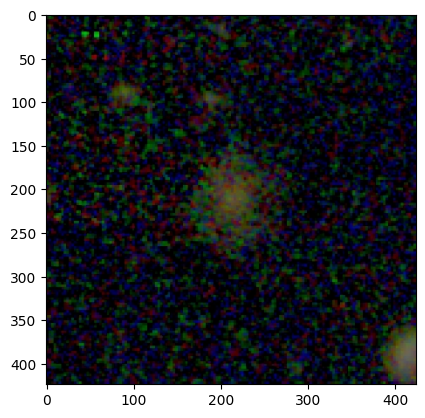

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
img, labels = gzdataset[np.random.randint(len(gzdataset))]
plt.imshow(img)
print(labels)
print(img.size)

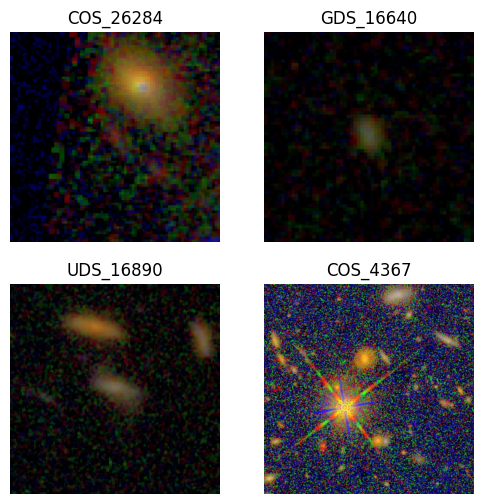

In [ ]:
from ml_sandbox.dataset import show_sample_images
for i in range(3,4):
    show_sample_images(gzdataset, num_images=i+1)

In [ ]:
from ml_sandbox.models import make_pca_rf_pipeline
from ml_sandbox.train_eval import train_eval_loop_skl
model = make_pca_rf_pipeline(n_pca_comp=150, n_trees=100, random_state=42)


In [ ]:
from torch.utils.data import random_split
train, test = random_split(gzdataset, [0.95, 0.05],)


# xtrain, ytrain = zip(*[train[i] for i in range(len(train))])
xtest, ytest = zip(*[test[i] for i in range(len(test))])

print(xtest[0].shape, ytest[0])


In [13]:
trained_model, test_accuracy, y_test, y_pred = train_eval_loop_skl(model, test, random_state=42)

ValueError: Found array with dim 4, while dim <= 2 is required by PCA.